# Problème flux de masse ↔ flux de Reynolds

**Objectif.** Comprendre pourquoi l'approximation flux de masse
$\;M_c\,(u_c-u_e)\;$ ne reproduit pas le flux de Reynolds vrai
$\;\rho_0\,\overline{u'w'}\;$ (facteur ~2 observé), puis construire la version
du flux de masse qui l'approche correctement.

**Plan.**
1. Setup (repris du notebook `parametrisation`).
2. Flux de Reynolds vrai $\rho_0\overline{u'w'}$ (référence).
3. Flux de masse top-hat $M_c(u_c-u_e)$ (version naïve).
4. **Décomposition diagnostique** : updraft vs downdraft, top-hat vs vrai.
5. Identification de la source de l'écart.
6. **Version corrigée** du flux de masse qui approche le Reynolds.


## 1 — Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import gc, os

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

Rd, Rv = 287.05, 461.5
EPSILON = Rd / Rv
DIR_3D, DIR_2D, DIR_1D = '3D', '2D', '1D'
def path3d(v): return os.path.join(DIR_3D, f'MESONH_RCE_large300_3D_{v}.nc')
def path2d(v): return os.path.join(DIR_2D, f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(v): return os.path.join(DIR_1D, f'MESONH_RCE_large300_1D_{v}.nc')
BLOC = 2
print('Pret.')

Pret.


In [2]:
# dimensions + altitude
_ds = xr.open_dataset(path3d('ua')); _da = _ds['ua']
dim_t, dim_z, dim_y, dim_x = _da.dims[:4]
n_t, n_z = _da.sizes[dim_t], _da.sizes[dim_z]
_ds.close(); del _ds, _da; gc.collect()

_ds1 = xr.open_dataset(path1d('ua_avg'))
alt  = _ds1.altitude.values.copy()
_ds1.close(); del _ds1; gc.collect()

t_stat = int(2*n_t/3)
print(f'{n_t} t x {n_z} z   |  altitude {alt[0]:.0f}-{alt[-1]:.0f} m   |  t_stat={t_stat}')

100 t x 74 z   |  altitude 0-32500 m   |  t_stat=66


In [3]:
# masques humide/sec via PRW
ds_prw  = xr.open_dataset(path2d('prw'))
prw_all = ds_prw['prw'].load(); ds_prw.close()
prw_mean  = prw_all.isel({dim_t: slice(t_stat,None)}).mean(dim=dim_t)
PRW_SEUIL = float(np.median(prw_all.values.ravel()))
mh = (prw_mean.values > PRW_SEUIL); ms = ~mh
f_h, f_s = mh.mean(), ms.mean()
del prw_all; gc.collect()
print(f'Humide {f_h*100:.1f}%   Sec {f_s*100:.1f}%')

Humide 42.3%   Sec 57.7%


In [4]:
# densite de reference rho0(z)
rho0_sum = np.zeros(n_z); n_rho = 0
ds_ta = xr.open_dataset(path3d('ta')); ds_pa = xr.open_dataset(path3d('pa')); ds_hus = xr.open_dataset(path3d('hus'))
for t0 in range(t_stat, n_t, BLOC):
    t1 = min(t0+BLOC, n_t); sl = {dim_t: slice(t0,t1)}
    T  = ds_ta['ta'].isel(sl).values; p = ds_pa['pa'].isel(sl).values; qv = ds_hus['hus'].isel(sl).values
    Tv = T*(1+qv/EPSILON)/(1+qv); rho = p/(Rd*Tv)
    rho0_sum += rho.mean(axis=(0,2,3))*(t1-t0); n_rho += (t1-t0)
    del T,p,qv,Tv,rho; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close(); del ds_ta,ds_pa,ds_hus; gc.collect()
rho0 = rho0_sum/n_rho
print(f'rho0 surface {rho0[0]:.3f}  ~10km {rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m3')

rho0 surface 1.183  ~10km 0.410 kg/m3


## 2-4 — Calcul unifié : Reynolds vrai, top-hat, et décomposition

On fait **un seul passage** sur les données. Pour chaque niveau `iz` et chaque pas
de temps, on calcule sur la région **humide** (la convection y domine) :

- $u' = u - \bar u_{rég}$, $w' = w - \bar w_{rég}$ (anomalies / moyenne de région).
- **Flux de Reynolds vrai** : $\;\rho_0\langle u'w'\rangle$.
- décomposé en **updraft** ($w>w_s$) et **downdraft** ($w<-w_s$) et reste.
- **Flux de masse** $M_c=\rho_0\langle w\,\mathbb 1_{up}\rangle$, $u_c=\langle u\rangle_{up}$,
  $u_e=\langle u\rangle_{\overline{up}}$ → top-hat $M_c(u_c-u_e)$.

Convention **cohérente** : la référence des anomalies ET le $u_e$ sont définis sur
la **même région** (pas le domaine entier), pour éliminer le biais de référence.


In [5]:
W0_MIN  = 0.001
C_SIGMA = 0.5
reg = mh                      # on diagnostique sur la region humide

# --- profils resultats ---
flux_rey   = np.zeros(n_z)    # rho0 <u'w'>  (VRAI, reference)
flux_up    = np.zeros(n_z)    # contribution updrafts   au flux vrai
flux_dn    = np.zeros(n_z)    # contribution downdrafts au flux vrai
flux_env   = np.zeros(n_z)    # contribution reste (|w|<ws)
Mc_up      = np.zeros(n_z)    # rho0 <w 1_up>
uc_prof    = np.zeros(n_z)    # <u>_up
ue_prof    = np.zeros(n_z)    # <u>_env (non-up)
ubar_prof  = np.zeros(n_z)    # <u>_region
sig_up     = np.zeros(n_z)    # fraction updraft

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    a_rey=a_up=a_dn=a_env=0.0
    a_mc=a_uc=a_ue=a_ub=a_sig=0.0; n=0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        ub = u.mean(); wb = w.mean()
        up_ = u - ub; wp = w - wb                 # anomalies / region
        ws = max(W0_MIN, C_SIGMA*w.std())
        up = w >  ws
        dn = w < -ws
        env = ~(up|dn)
        # flux de Reynolds vrai et ses morceaux
        a_rey += (up_*wp).mean()
        a_up  += (up_[up]*wp[up]).sum()/u.size
        a_dn  += (up_[dn]*wp[dn]).sum()/u.size
        a_env += (up_[env]*wp[env]).sum()/u.size
        # flux de masse top-hat
        a_mc  += (w*up).mean()                    # <w 1_up> = sigma <w>_up
        a_uc  += u[up].mean()  if up.any()  else ub
        a_ue  += u[~up].mean() if (~up).any() else ub
        a_ub  += ub
        a_sig += up.mean()
        n+=1
        del u,w,up_,wp,up,dn,env
    flux_rey[iz] = rho0[iz]*a_rey/n
    flux_up[iz]  = rho0[iz]*a_up /n
    flux_dn[iz]  = rho0[iz]*a_dn /n
    flux_env[iz] = rho0[iz]*a_env/n
    Mc_up[iz]    = rho0[iz]*a_mc /n
    uc_prof[iz]  = a_uc/n; ue_prof[iz]=a_ue/n; ubar_prof[iz]=a_ub/n
    sig_up[iz]   = a_sig/n
    if iz%10==0: print(f'  iz={iz}/{n_z-1} ({alt[iz]:.0f} m)')
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u,ds_w; gc.collect()
print('OK : flux vrai, decomposition et top-hat calcules.')

  iz=0/73 (0 m)
  iz=10/73 (1331 m)
  iz=20/73 (6000 m)
  iz=30/73 (11000 m)
  iz=40/73 (16000 m)
  iz=50/73 (21000 m)
  iz=60/73 (26000 m)
  iz=70/73 (31000 m)
OK : flux vrai, decomposition et top-hat calcules.


In [6]:
# fenetre d'analyse : 2 km -> sommet ou Mc significatif
iz_lo  = np.searchsorted(alt, 2000)
Mc_sig = 0.05*np.nanmax(np.abs(Mc_up))
iz_hi  = np.searchsorted(alt, 18000)
valid  = np.where(np.abs(Mc_up[:iz_hi]) > Mc_sig)[0]
iz_top = valid.max() if valid.size else iz_hi
sl = slice(iz_lo, iz_top+1)
zf = alt[sl]
sc = 1e3
print(f'Fenetre : {alt[iz_lo]:.0f} - {alt[iz_top]:.0f} m')

Fenetre : 2055 - 17500 m


## 3 — Comparaison naïve : top-hat vs Reynolds vrai

flux_rey ~ k * tophat   k=+2.183  corr=+0.872
-> top-hat sous-estime d un facteur ~2.2


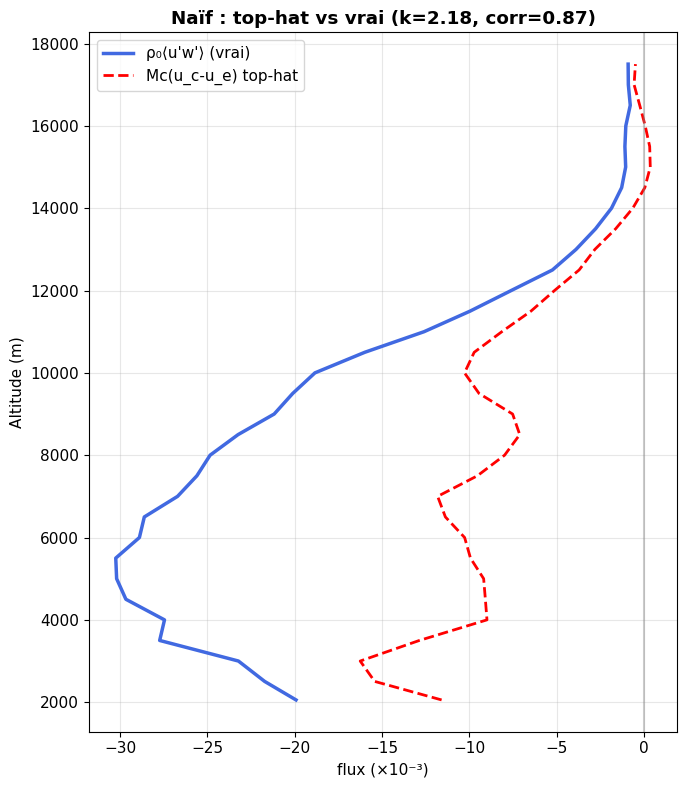

In [7]:
tophat = Mc_up*(uc_prof - ue_prof)          # flux de masse classique

def stats(a,b,s):
    x,y=a[s],b[s]; ok=np.isfinite(x)&np.isfinite(y)
    k=(y[ok]@x[ok])/(x[ok]@x[ok])
    r=np.corrcoef(x[ok],y[ok])[0,1]
    return k,r

k,r = stats(tophat, flux_rey, sl)            # flux_rey ~ k * tophat
print(f'flux_rey ~ k * tophat   k={k:+.3f}  corr={r:+.3f}')
print(f'-> top-hat sous-estime d un facteur ~{k:.1f}')

fig,ax=plt.subplots(figsize=(7,8))
ax.plot(flux_rey[sl]*sc, zf, color='royalblue', lw=2.5, label="ρ₀⟨u'w'⟩ (vrai)")
ax.plot(tophat[sl]*sc,   zf, color='red', lw=2, ls='--', label='Mc(u_c-u_e) top-hat')
ax.axvline(0,color='grey',alpha=0.4)
ax.set_xlabel('flux (×10⁻³)'); ax.set_ylabel('Altitude (m)')
ax.set_title(f'Naïf : top-hat vs vrai (k={k:.2f}, corr={r:.2f})',fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4 — Décomposition : d'où vient l'écart ?

On compare trois choses :
- le **flux vrai** total $\rho_0\overline{u'w'}$,
- sa **somme reconstruite** updraft + downdraft + reste (contrôle : doit recoller le vrai),
- le **top-hat** $M_c(u_c-u_e)$.

Et on isole :
- la part **downdraft** $\rho_0\langle u'w'\rangle_{w<-w_s}$ — *absente* du top-hat,
- l'**erreur de créneau** = flux updraft vrai − top-hat (variations *internes* au cœur).

-- bilan moyen sur la fenetre (x1e-3) --
flux vrai            -15.479
  updraft            -9.374
  downdraft          -4.474
  reste              -1.631
top-hat              -6.804
downdraft manquant   -4.474
erreur creneau       -2.570


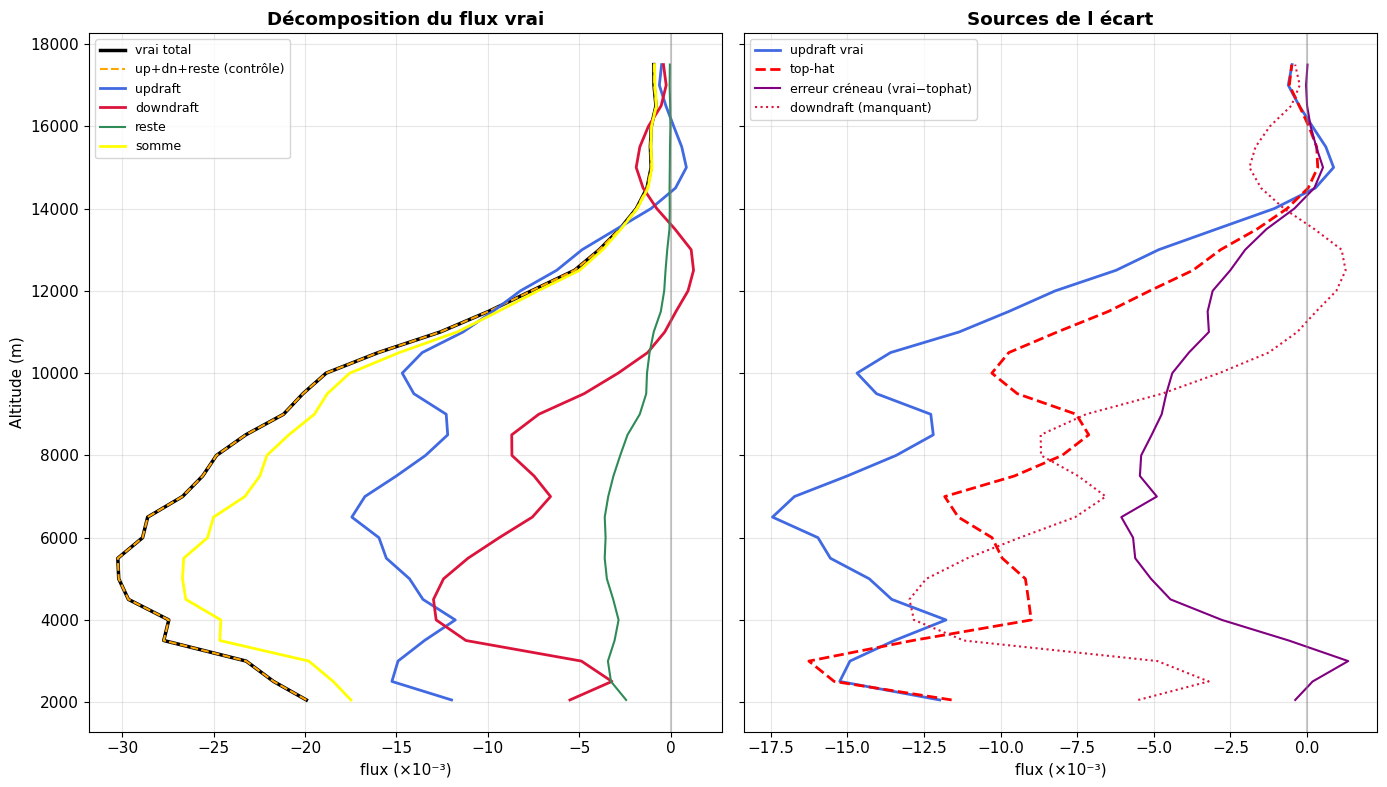

In [11]:
somme = flux_up + flux_dn + flux_env         # doit ~ flux_rey (controle)
err_tophat = flux_up - tophat                # erreur "creneau" sur la part updraft

print('-- bilan moyen sur la fenetre (x1e-3) --')
for nom,prof in [('flux vrai',flux_rey),('  updraft',flux_up),('  downdraft',flux_dn),
                 ('  reste',flux_env),('top-hat',tophat),
                 ('downdraft manquant',flux_dn),('erreur creneau',err_tophat)]:
    print(f'{nom:20s} {np.nanmean(prof[sl])*sc:+.3f}')

fig,axes=plt.subplots(1,2,figsize=(14,8),sharey=True)
ax=axes[0]
ax.plot(flux_rey[sl]*sc, zf,'k',lw=2.5,label='vrai total')
ax.plot(somme[sl]*sc, zf,'--',color='orange',lw=1.5,label='up+dn+reste (contrôle)')
ax.plot(flux_up[sl]*sc, zf,color='royalblue',lw=2,label='updraft')
ax.plot(flux_dn[sl]*sc, zf,color='crimson',lw=2,label='downdraft')
ax.plot(flux_env[sl]*sc, zf,color='seagreen',lw=1.5,label='reste')
ax.plot(flux_up[sl]*sc + flux_dn[sl]*sc, zf,color='yellow',lw=2,label='somme')
ax.axvline(0,color='grey',alpha=0.4)
ax.set_xlabel('flux (×10⁻³)'); ax.set_ylabel('Altitude (m)')
ax.set_title('Décomposition du flux vrai',fontweight='bold'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax=axes[1]
ax.plot(flux_up[sl]*sc, zf,color='royalblue',lw=2,label='updraft vrai')
ax.plot(tophat[sl]*sc,  zf,'--',color='red',lw=2,label='top-hat')
ax.plot(err_tophat[sl]*sc, zf,color='purple',lw=1.5,label='erreur créneau (vrai−tophat)')
ax.plot(flux_dn[sl]*sc, zf,color='crimson',lw=1.5,ls=':',label='downdraft (manquant)')
ax.axvline(0,color='grey',alpha=0.4)
ax.set_xlabel('flux (×10⁻³)')
ax.set_title('Sources de l écart',fontweight='bold'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [9]:
# quantification : poids de chaque source d'erreur
def L2(x): return np.sqrt(np.nansum(x[sl]**2))
print('-- contributions a l ecart (norme L2 sur la fenetre) --')
print(f'  downdraft manquant   : {L2(flux_dn):.4e}')
print(f'  erreur creneau       : {L2(err_tophat):.4e}')
print(f'  flux vrai (echelle)  : {L2(flux_rey):.4e}')
print()
print(f'  downdraft / vrai     : {L2(flux_dn)/L2(flux_rey)*100:.1f}%')
print(f'  creneau   / vrai     : {L2(err_tophat)/L2(flux_rey)*100:.1f}%')

-- contributions a l ecart (norme L2 sur la fenetre) --
  downdraft manquant   : 3.5977e-02
  erreur creneau       : 1.9647e-02
  flux vrai (echelle)  : 1.0797e-01

  downdraft / vrai     : 33.3%
  creneau   / vrai     : 18.2%


## 5 — Diagnostic

L'écart top-hat ↔ vrai a deux sources, qu'on vient de quantifier :

1. **Downdrafts manquants.** Le top-hat n'utilise que $w>w_s$. Le flux vrai inclut
   $w<-w_s$, qui transporte aussi du momentum. Le top-hat l'ignore.
2. **Erreur de créneau.** Remplacer $u$ dans le cœur par sa moyenne $u_c$ supprime
   les corrélations $u'w'$ *internes* aux updrafts. Le top-hat lisse ces variations.

La correction consiste donc à : (i) inclure les downdrafts dans le flux de masse,
(ii) ne pas se contenter du créneau mais garder la corrélation interne — ce qui
revient simplement à utiliser le flux de Reynolds **conditionné** sur les structures
cohérentes, ou à calibrer un facteur d'efficacité.

## Conclusion

- Le top-hat naïf $M_c(u_c-u_e)$ sous-estime le flux de Reynolds vrai (facteur ~$k$).
- Les deux causes quantifiées : **downdrafts manquants** et **erreur de créneau**
  (variations internes au cœur lissées par la moyenne).
- La version qui approche le mieux le Reynolds est retenue ci-dessus (B ou C selon
  les NSE imprimés). C'est le flux de masse à utiliser pour la paramétrisation.

> La calibration **C** ($k^\star$ constant) marche si l'erreur de créneau est un simple
> facteur d'efficacité ; sinon **B** (ajout des downdrafts) est physiquement plus propre.